# lrdata to MuData

### Load packages

In [1]:
from pathlib import Path
import scanpy as sc
import squidpy as sq
import liana as li
import pandas as pd
import os

/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in futur

## Load and Prep Data

In [2]:
# file_path = "data/MERFISH_mouse_brain/WB_MERFISH_animal2_coronal.h5ad"
# backup_url = "https://datasets.cellxgene.cziscience.com/93c3bb97-ea05-4ee0-a760-a1508cd04612.h5ad"

# if os.path.exists(file_path):
#     adata = sc.read(file_path)
# else:
#     adata = sc.read(
#     file_path,
#     backup_url=backup_url
# )

# adata = adata[adata.obs["brain_section_label"] == "C57BL6J-2.039"]
# adata.var_names = adata.var["gene_name"]
# adata.obsm['spatial'] = adata.obsm['X_spatial_coords']

In [3]:
data_path = Path("../../data/agne_cd/")
adata = sc.read_h5ad(data_path / "RUN1_SLIDE2_S6.h5ad")

adata.obsm['spatial'] = adata.obs[['x', 'y']].to_numpy()

adata.obs['cell_type'] = adata.obs['CellAnnotation.Level0']

In [4]:
# adata = sc.read("../../data/kuppe_heart19.h5ad", backup_url='https://figshare.com/ndownloader/files/41501073?private_link=4744950f8768d5c8f68c')
# adata.obs['cell_type'] = adata.obs['celltype_niche']

# # Rename to more informative names
# full_names = {'Adipo': 'Adipocytes',
#               'CM': 'Cardiomyocytes',
#               'Endo': 'Endothelial',
#               'Fib': 'Fibroblasts',
#               'PC': 'Pericytes',
#               'prolif': 'Proliferating',
#               'vSMCs': 'Vascular_SMCs',
#               }
# # but only for the ones that are in the data
# adata.obsm['compositions'].columns = [full_names.get(c, c) for c in adata.obsm['compositions'].columns]

In [5]:
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

... storing 'SAMPLE' as categorical
... storing 'TYPE' as categorical
... storing 'LOCATION' as categorical
... storing 'CellAnnotation.Level3' as categorical
... storing 'CellAnnotation.Level0' as categorical
... storing 'cell_type' as categorical


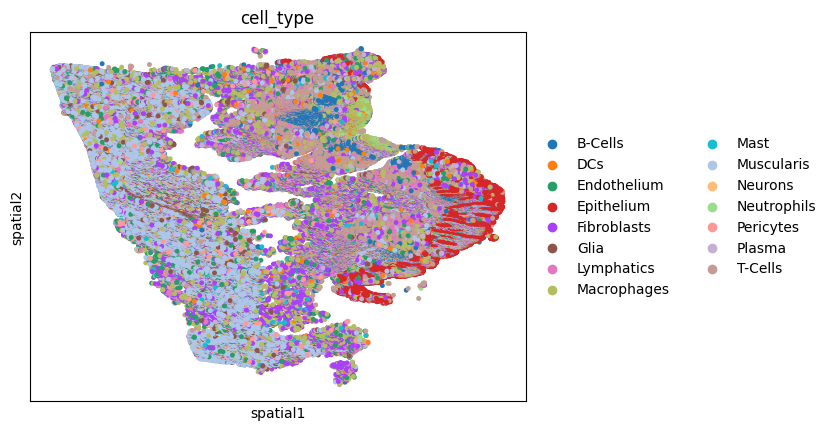

In [6]:
sc.pl.embedding(adata, basis="spatial", color=["cell_type"], wspace=0.4, s=50)

Use the chosen bandwidth based on this exploration to compute the final spatial connectivity matrix $W_{ij}$.

In [7]:
li.ut.spatial_neighbors(adata=adata, bandwidth=30)

#### Visualize proximity

/data/ddimitrov/repos/liana-py/src/liana/plotting/_connectivity_plot.py:38: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.


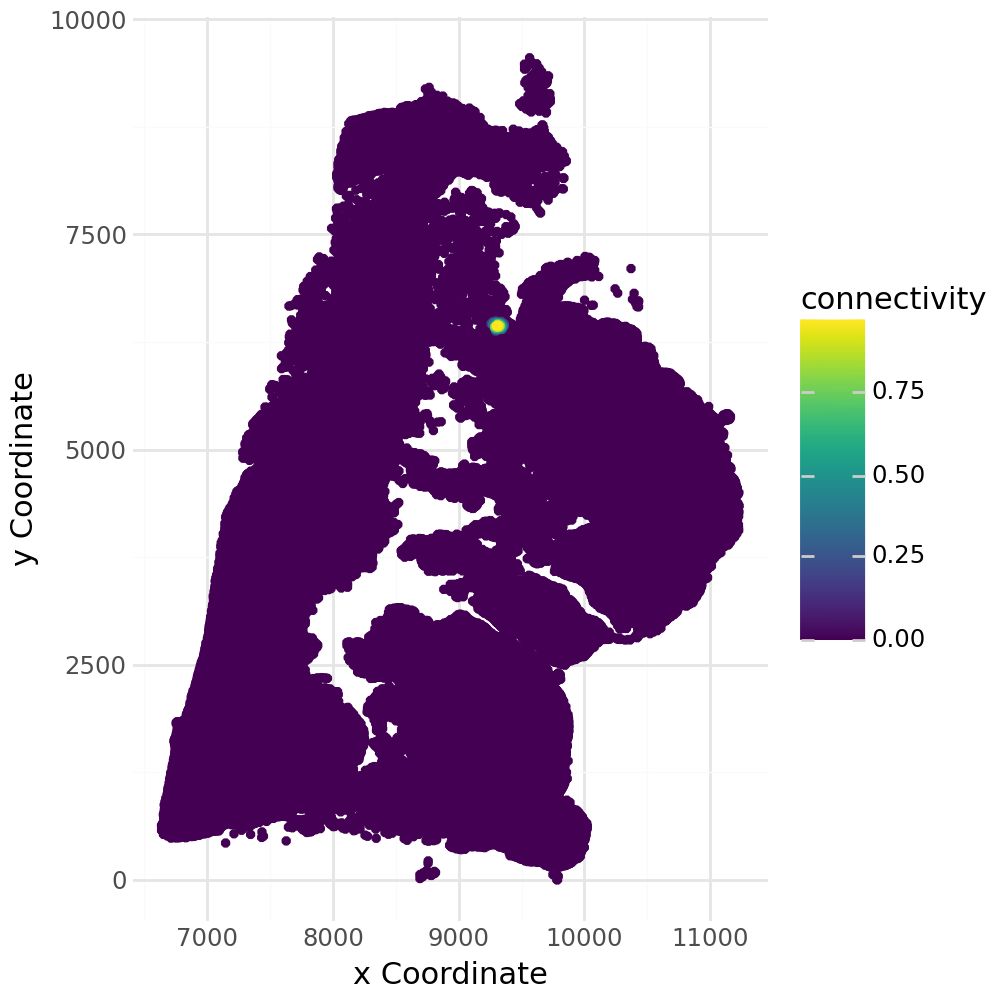

In [8]:
li.pl.connectivity(adata, idx=1000, size=1, figure_size=(5, 5))

### Find spatially variable genes (SVGs) using Morans'I

In [9]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, show_progress_bar=True)

In [10]:
adata.uns['moranI']
#I: Moran’s I score for each gene
#pval: p-value (if permutation test is used)
#var_norm: Variance used to normalize Moran’s I (used internally for significance).
#pval_norm_fdr_bh: FDR-adjusted p-value (Benjamini-Hochberg correction) for multiple testing.

,I,pval_norm,var_norm,pval_norm_fdr_bh
IL1B,0.446302,0.000000,1.599799e-07,0.000000
HCAR3,0.426880,0.000000,1.599799e-07,0.000000
REG1A,0.419123,0.000000,1.599799e-07,0.000000
REG1B,0.413456,0.000000,1.599799e-07,0.000000
OLFM4,0.400763,0.000000,1.599799e-07,0.000000
...,...,...,...,...
EIF5AL1,-0.000486,0.114685,1.599799e-07,0.128973
ZHX3,-0.000534,0.092946,1.599799e-07,0.105292
GRM2,-0.000542,0.089828,1.599799e-07,0.101828
INCA1,-0.000591,0.071512,1.599799e-07,0.081536


### Filter by spatially variable genes (SVGs)

In [11]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

1635

In [12]:
adata = adata[:, svgs]

## Compute inflow score 

#### Get LR database

- **Mouse**? Convert LR database to mouse gene symbol

In [13]:
lrdata = li.mt.inflow(adata=adata, 
                resource_name='consensus', 
                groupby='cell_type',
                # obsm_key='compositions',
                use_raw=False,
                nz_prop=0.01
                )
lrdata.shape

/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/data/ddimitrov/repos/liana-py/src/liana/method/sp/_inflow.py:318: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


(191794, 4550)

### Optional: filter data to keep only spatially variable LR interaction

In [14]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

In [15]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]
len(svis)

4058

In [16]:
lrdata = lrdata[:,svis]
lrdata.uns['moranI'].sort_values("I").tail(10)

,I,pval_norm,var_norm,pval_norm_fdr_bh
Neutrophils^C3^ITGAX,0.383486,0.0,1.599799e-07,0.0
B-Cells^LGALS9^PTPRC,0.384375,0.0,1.599799e-07,0.0
Neutrophils^CSF1^CSF3R,0.395376,0.0,1.599799e-07,0.0
B-Cells^CD22^PTPRC,0.400239,0.0,1.599799e-07,0.0
B-Cells^ST6GAL1^CD22,0.412131,0.0,1.599799e-07,0.0
DCs^SPP1^CD44,0.416123,0.0,1.599799e-07,0.0
B-Cells^CXCL12^CXCR4,0.425113,0.0,1.599799e-07,0.0
Macrophages^SPP1^CD44,0.433519,0.0,1.599799e-07,0.0
B-Cells^C3^CD19,0.471634,0.0,1.599799e-07,0.0
B-Cells^CXCL14^CXCR4,0.473389,0.0,1.599799e-07,0.0


### Convert lrdata to muData

In [17]:
import scanpy as sc
import mudata as md
import anndata as an

from liana._constants import DefaultValues as V

from liana._docs import d
from liana._logging import _logg


def anndata_to_mdata(
    adata,
    groupby,
    min_cells,
    lr_sep,
    by_var,
    verbose,

):
    """
    Convert AnnData object to MultiData object.

    Args:
    ----------
    %(adata)s
    %(groupby)s
    %(min_cells)s
    by_var: bool, optional
        Whether to group by variables instead of observations. Default is False.
    %(lr_sep)s
    %(verbose)s

    Returns
    -------
        MultiData: A new MultiData object.
    """

    adata_dict = {}

    if by_var:
        # Extract modalities from variable name prefixes before the `lr_sep` separator
        modalities = adata.var.index.str.split(lr_sep, expand=True).get_level_values(0).unique().tolist()

        for modality in modalities:
            if verbose:
                _logg(f"Processing modality (from var): {modality}")

            # Filter variables (genes) belonging to the current modality
            var_filter = adata.var.index.str.startswith(f"{modality}{lr_sep}")
            adata_mod = adata[:, var_filter].copy()

            # Apply gene filtering within this modality
            sc.pp.filter_genes(adata_mod, min_cells=min_cells)

            adata_dict[modality] = adata_mod
            if verbose:
                _logg(f"Modality {modality} (from var): {adata_mod.n_obs} cells, {adata_mod.n_vars} genes after filtering.")

    else:
        # Extract modalities from the observation annotation based on `groupby`
        modalities = adata.obs[groupby].unique().tolist()

        for modality in modalities:
            if verbose:
                _logg(f"Processing modality (from obs): {modality}")

            # Filter observations (cells) belonging to the current modality
            adata_mod = adata[adata.obs[groupby] == modality].copy()

            # Apply gene filtering
            sc.pp.filter_genes(adata_mod, min_cells=min_cells)


            adata_dict[modality] = adata_mod
            if verbose:
                _logg(f"Modality {modality} (from obs): {adata_mod.n_obs} cells, {adata_mod.n_vars} genes after filtering.")

    # Create and return a MuData object with filtered modalities
    mudata = md.MuData(adata_dict)
    return mudata
        

In [18]:
# lrdata_path  = Path("../../data/MERFISH_mouse_brain/")
# adata = sc.read_h5ad(lrdata_path / "lrdata_C57BL6J_2.039.h5ad")

In [19]:
lrdata.X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5624586 stored elements and shape (191794, 4058)>

In [20]:
# subset to random 20k cells
# lrdata = lrdata[lrdata.obs.sample(n=2000, random_state=42).index,:].copy()

In [21]:
mdata = anndata_to_mdata(
    adata = lrdata,
    groupby = "cell_type",
    min_cells=10,
    lr_sep = "^",
    by_var = True,
    verbose = True
    )

/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


In [22]:
mdata

MuData object with n_obs × n_vars = 191794 × 3967
  var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
  15 modalities
    B-Cells:	191794 x 264
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'log1p', 'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Macrophages:	191794 x 301
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'log1p', 'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    DCs:	191794 x 299
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'log1p', 'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Neutrophils:	191794 x 171
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'log1p', 'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Lymphatics:	191794 x 284
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'log1p', 'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Neurons:	191794 x 119
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'log1p', 'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Fibroblasts:	191794 x 307
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'log1p', 'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    T-Cells:	191794 x 293
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'log1p', 'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Plasma:	191794 x 297
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'log1p', 'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Muscularis:	191794 x 277
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'log1p', 'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spati

### Filter out modalities if ncells < 10 and/or ngenes <10

In [23]:
for mod_name, adatas in mdata.mod.items():
    cells, genes = adatas.shape
    print(f"Modality: {mod_name}, Cells: {cells}, Interactions: {genes}")

Modality: B-Cells, Cells: 191794, Interactions: 264
Modality: Macrophages, Cells: 191794, Interactions: 301
Modality: DCs, Cells: 191794, Interactions: 299
Modality: Neutrophils, Cells: 191794, Interactions: 171
Modality: Lymphatics, Cells: 191794, Interactions: 284
Modality: Neurons, Cells: 191794, Interactions: 119
Modality: Fibroblasts, Cells: 191794, Interactions: 307
Modality: T-Cells, Cells: 191794, Interactions: 293
Modality: Plasma, Cells: 191794, Interactions: 297
Modality: Muscularis, Cells: 191794, Interactions: 277
Modality: Epithelium, Cells: 191794, Interactions: 238
Modality: Pericytes, Cells: 191794, Interactions: 284
Modality: Glia, Cells: 191794, Interactions: 270
Modality: Mast, Cells: 191794, Interactions: 275
Modality: Endothelium, Cells: 191794, Interactions: 288


In [24]:
filtered_mods = {key: adata for key, adata in mdata.mod.items() if adata.shape[0] >= 10 and adata.shape[1] >= 10}
mdata.mod = filtered_mods

### Add global obs

In [25]:
mdata.obs = pd.DataFrame(index=mdata.obs_names)
mdata.var = pd.DataFrame(index=mdata.var_names)
mdata.obsm = {}
mdata.varm = {}

In [26]:
mdata.obsm = lrdata.obsm.copy()
mdata.uns = lrdata.uns.copy()

In [27]:
# for modality in mdata.mod:
#     #mdata.mod[modality].obs = pd.DataFrame(index=mdata.mod[modality].obs_names)
#     #mdata.mod[modality].var = pd.DataFrame(index=mdata.mod[modality].var_names)
#     #mdata.mod[modality].obsm = {}
#     mdata.mod[modality].uns = {}
#     mdata.mod[modality].obsp = {}

In [28]:
# adata.obs = adata.obs.reindex(mdata.obs_names)
# mdata.obs = adata.obs

In [29]:
# mdata

### Save mdata

In [30]:
# mdata.write_h5mu(data_path / "mdata_C57BL6J_2.039.h5mu")

# Run MOFA-Flex

In [31]:
import mudata as md
import mofaflex as mfl

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [32]:
# mdata = md.read_h5mu(data_path / "mdata_C57BL6J_2.039.h5mu")

In [33]:
# for mod_name, adatas in mdata.mod.items():
#     # add .obsm['spatial'] to each modality
#     adatas.obsm['spatial'] = mdata.obsm['spatial']

In [ ]:
data_opts = mfl.DataOptions(plot_data_overview=False) # , covariates_obs_key='spatial'


model_opts = mfl.ModelOptions(
        n_factors=10,
        factor_prior="Normal",
        likelihoods="Normal",
        weight_prior="SnS",
        nonnegative_factors=False,
        nonnegative_weights=False,
    )


training_opts = mfl.TrainingOptions(
        batch_size=10_000,
        n_particles=1,
        lr=0.003,
        max_epochs=25,
        save_path=str("model_sns_gp_C57BL6J_2.039.hdf5"),
        early_stopper_patience=10,
        device='cuda'
    )

In [35]:
model = mfl.MOFAFLEX(
    mdata,
    data_opts,
    model_opts,
    training_opts,
)

Sparse arrays are currently not supported by Dask. Dask will not be used and data arrays may be copied, resulting in high memory usage.
/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.

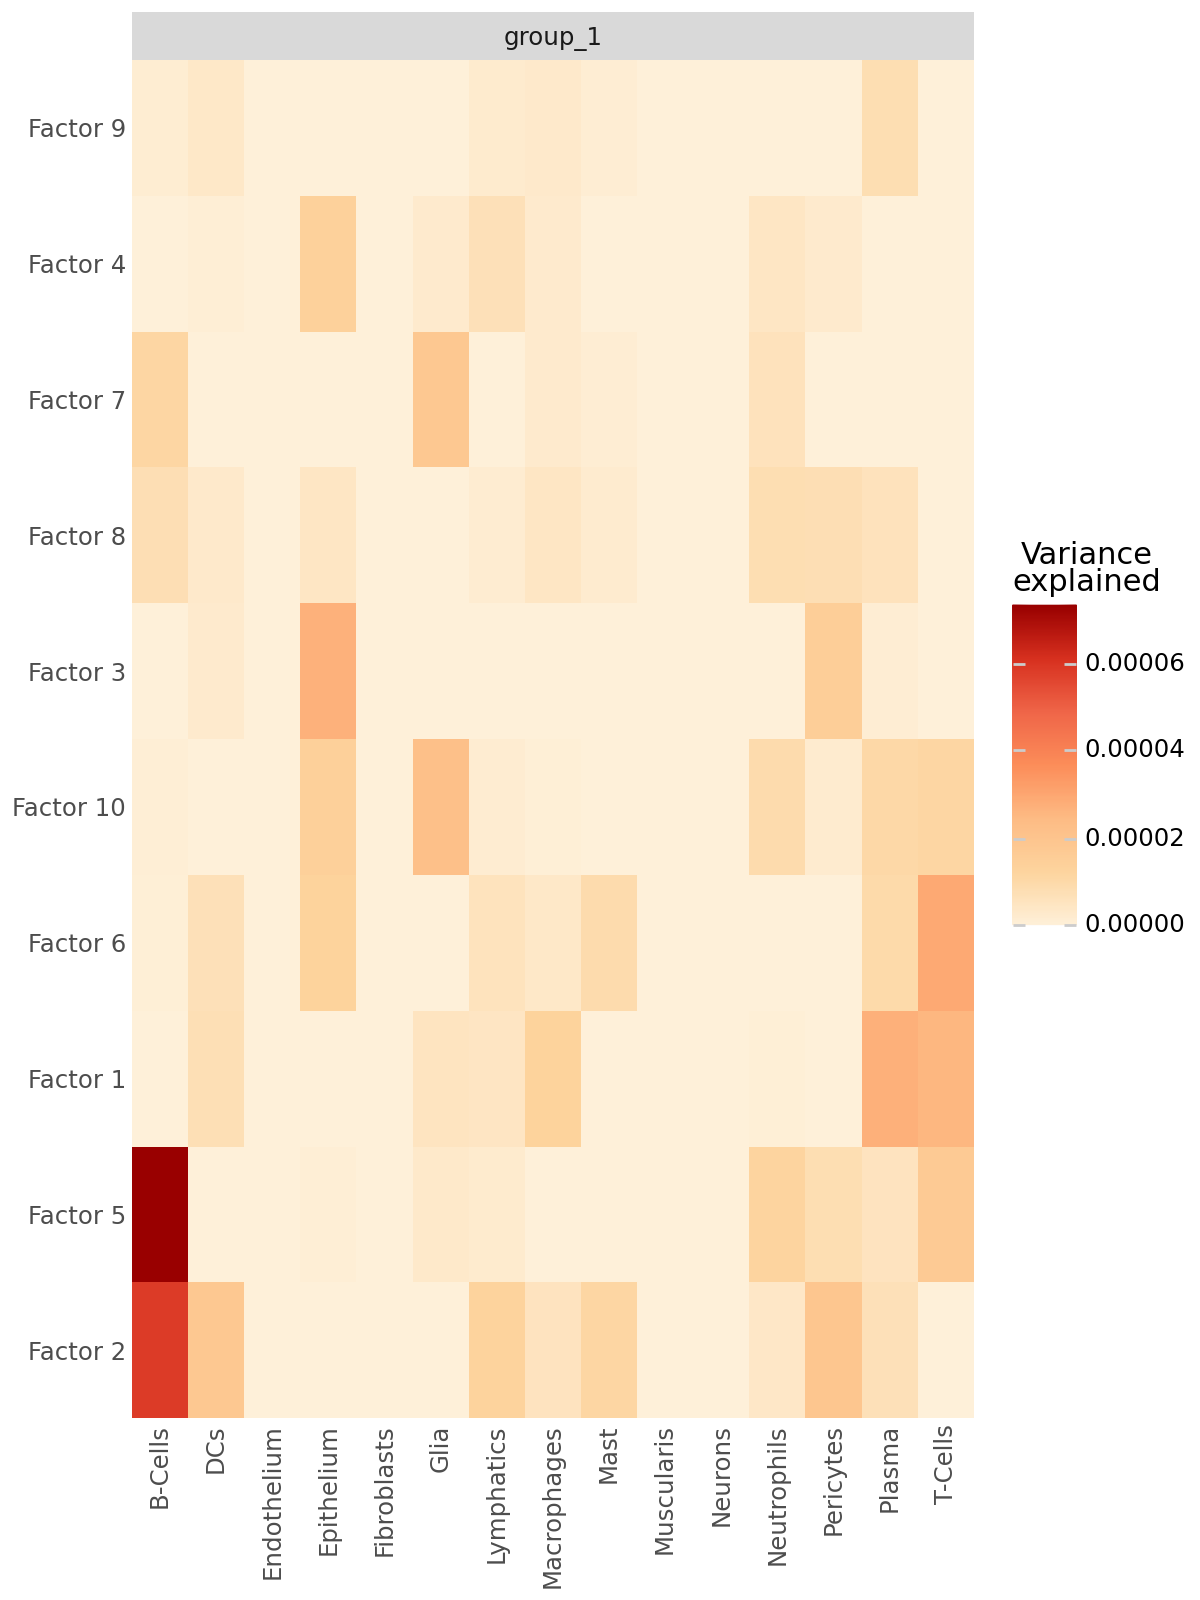

In [36]:
mfl.pl.variance_explained(model, figsize=(6, 8))

In [37]:
model

# Model Overview

In [38]:
#Load mofa model
model = mfl.MOFAFLEX.load("model_sns_gp_C57BL6J_2.039.hdf5")

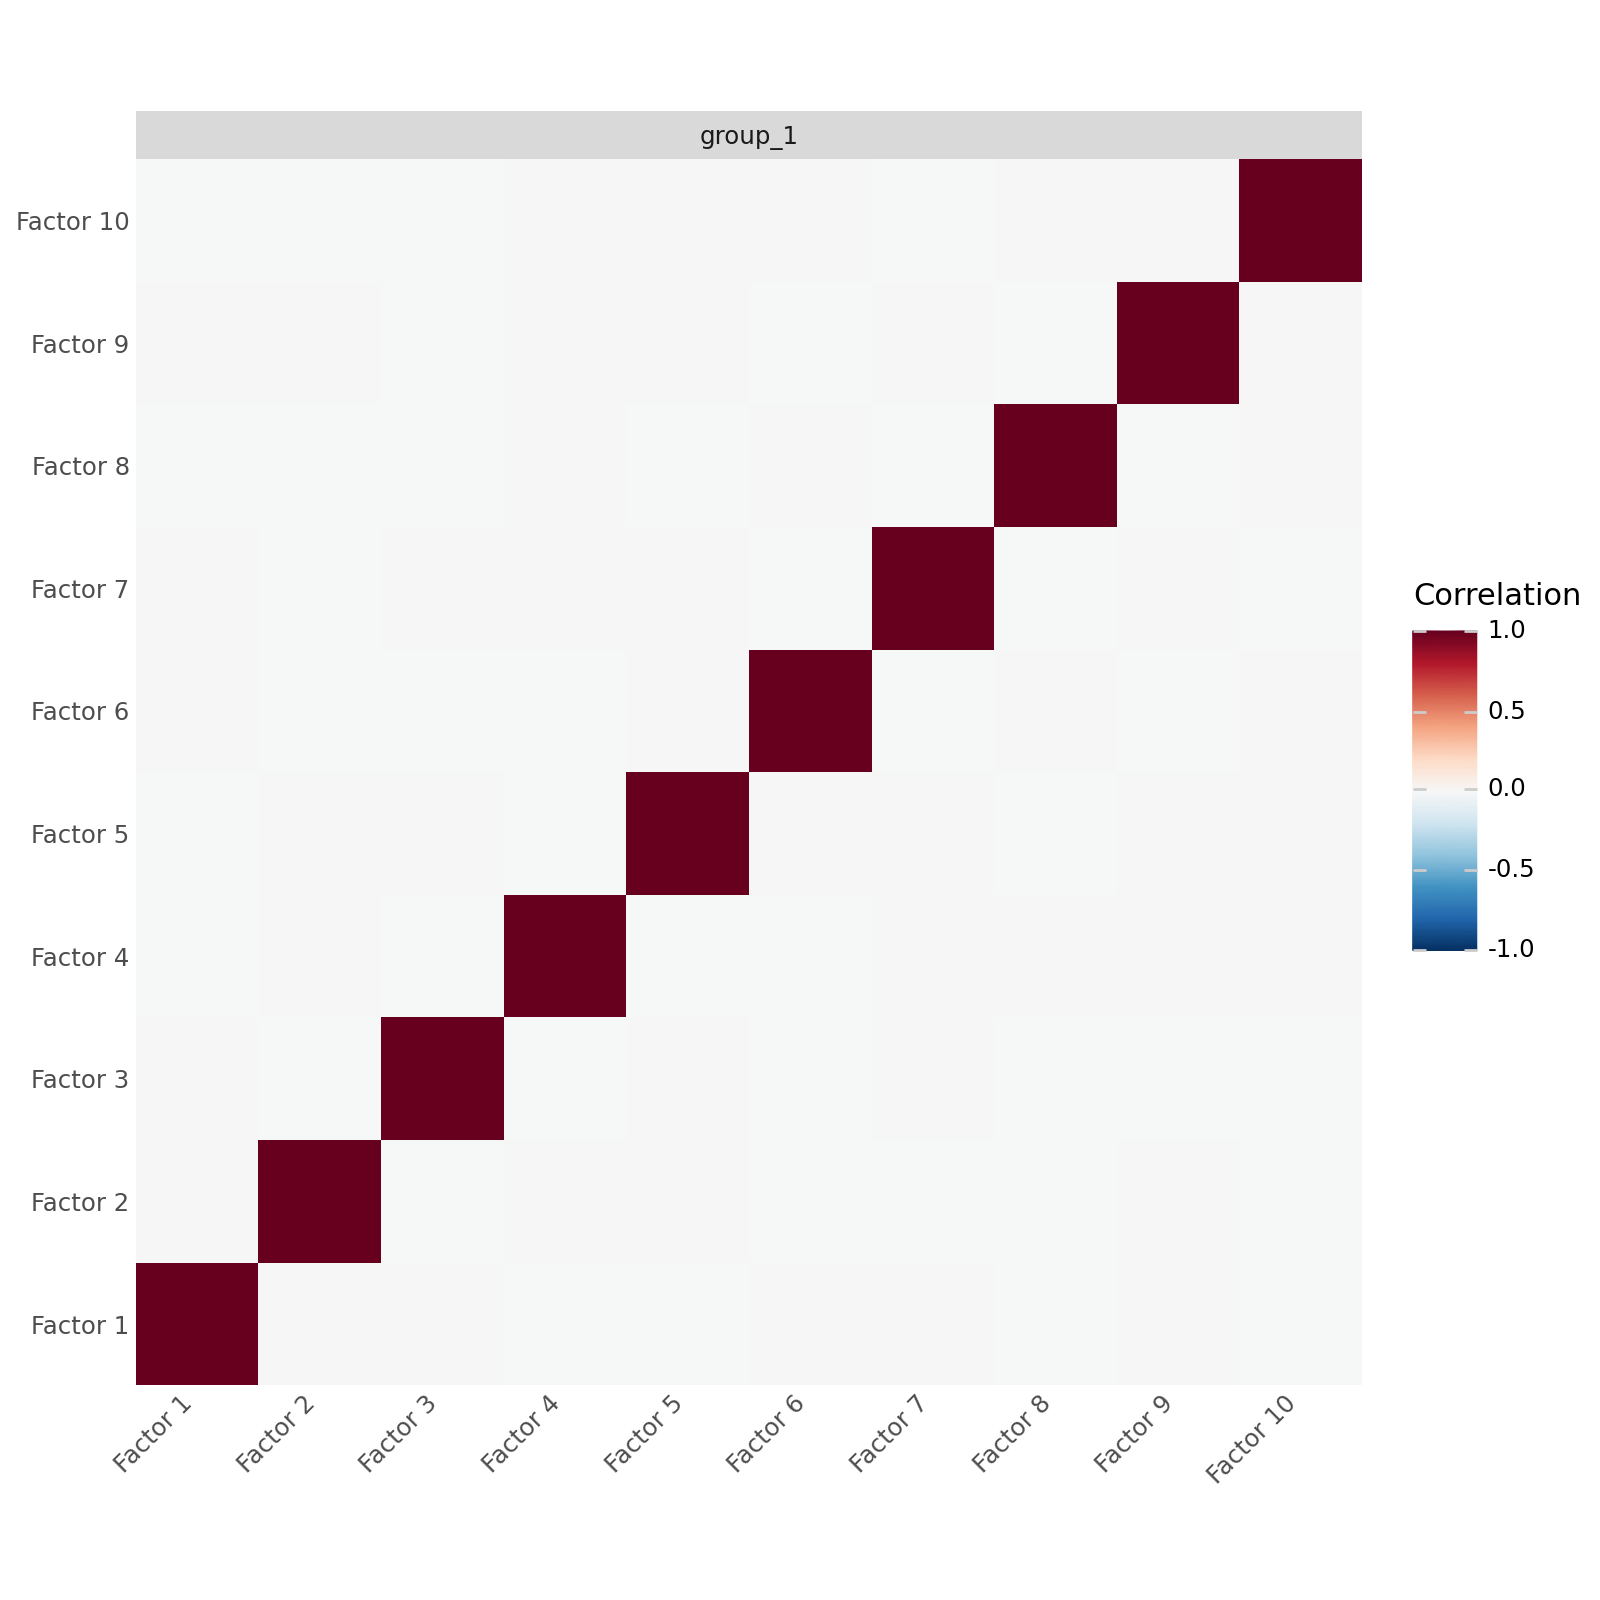

In [39]:
#Factor correlation
mfl.pl.factor_correlation(model)

In [40]:
def filter_factors(model, r2_thresh=0.99):
    r2_df = model.get_r2()["group_1"]
    r2_sorted = r2_df.sum(axis=1).sort_values(ascending=False)

    if r2_thresh < 1.0:
        r2_thresh = (r2_sorted.cumsum() / r2_sorted.sum() < r2_thresh).sum() + 1

    return r2_sorted.iloc[: int(r2_thresh)].index

In [41]:
factor_adata = model.get_factors("anndata")["group_1"][:, filter_factors(model)]

In [42]:
factor_adata

View of AnnData object with n_obs × n_vars = 191794 × 10
    obs: 'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'

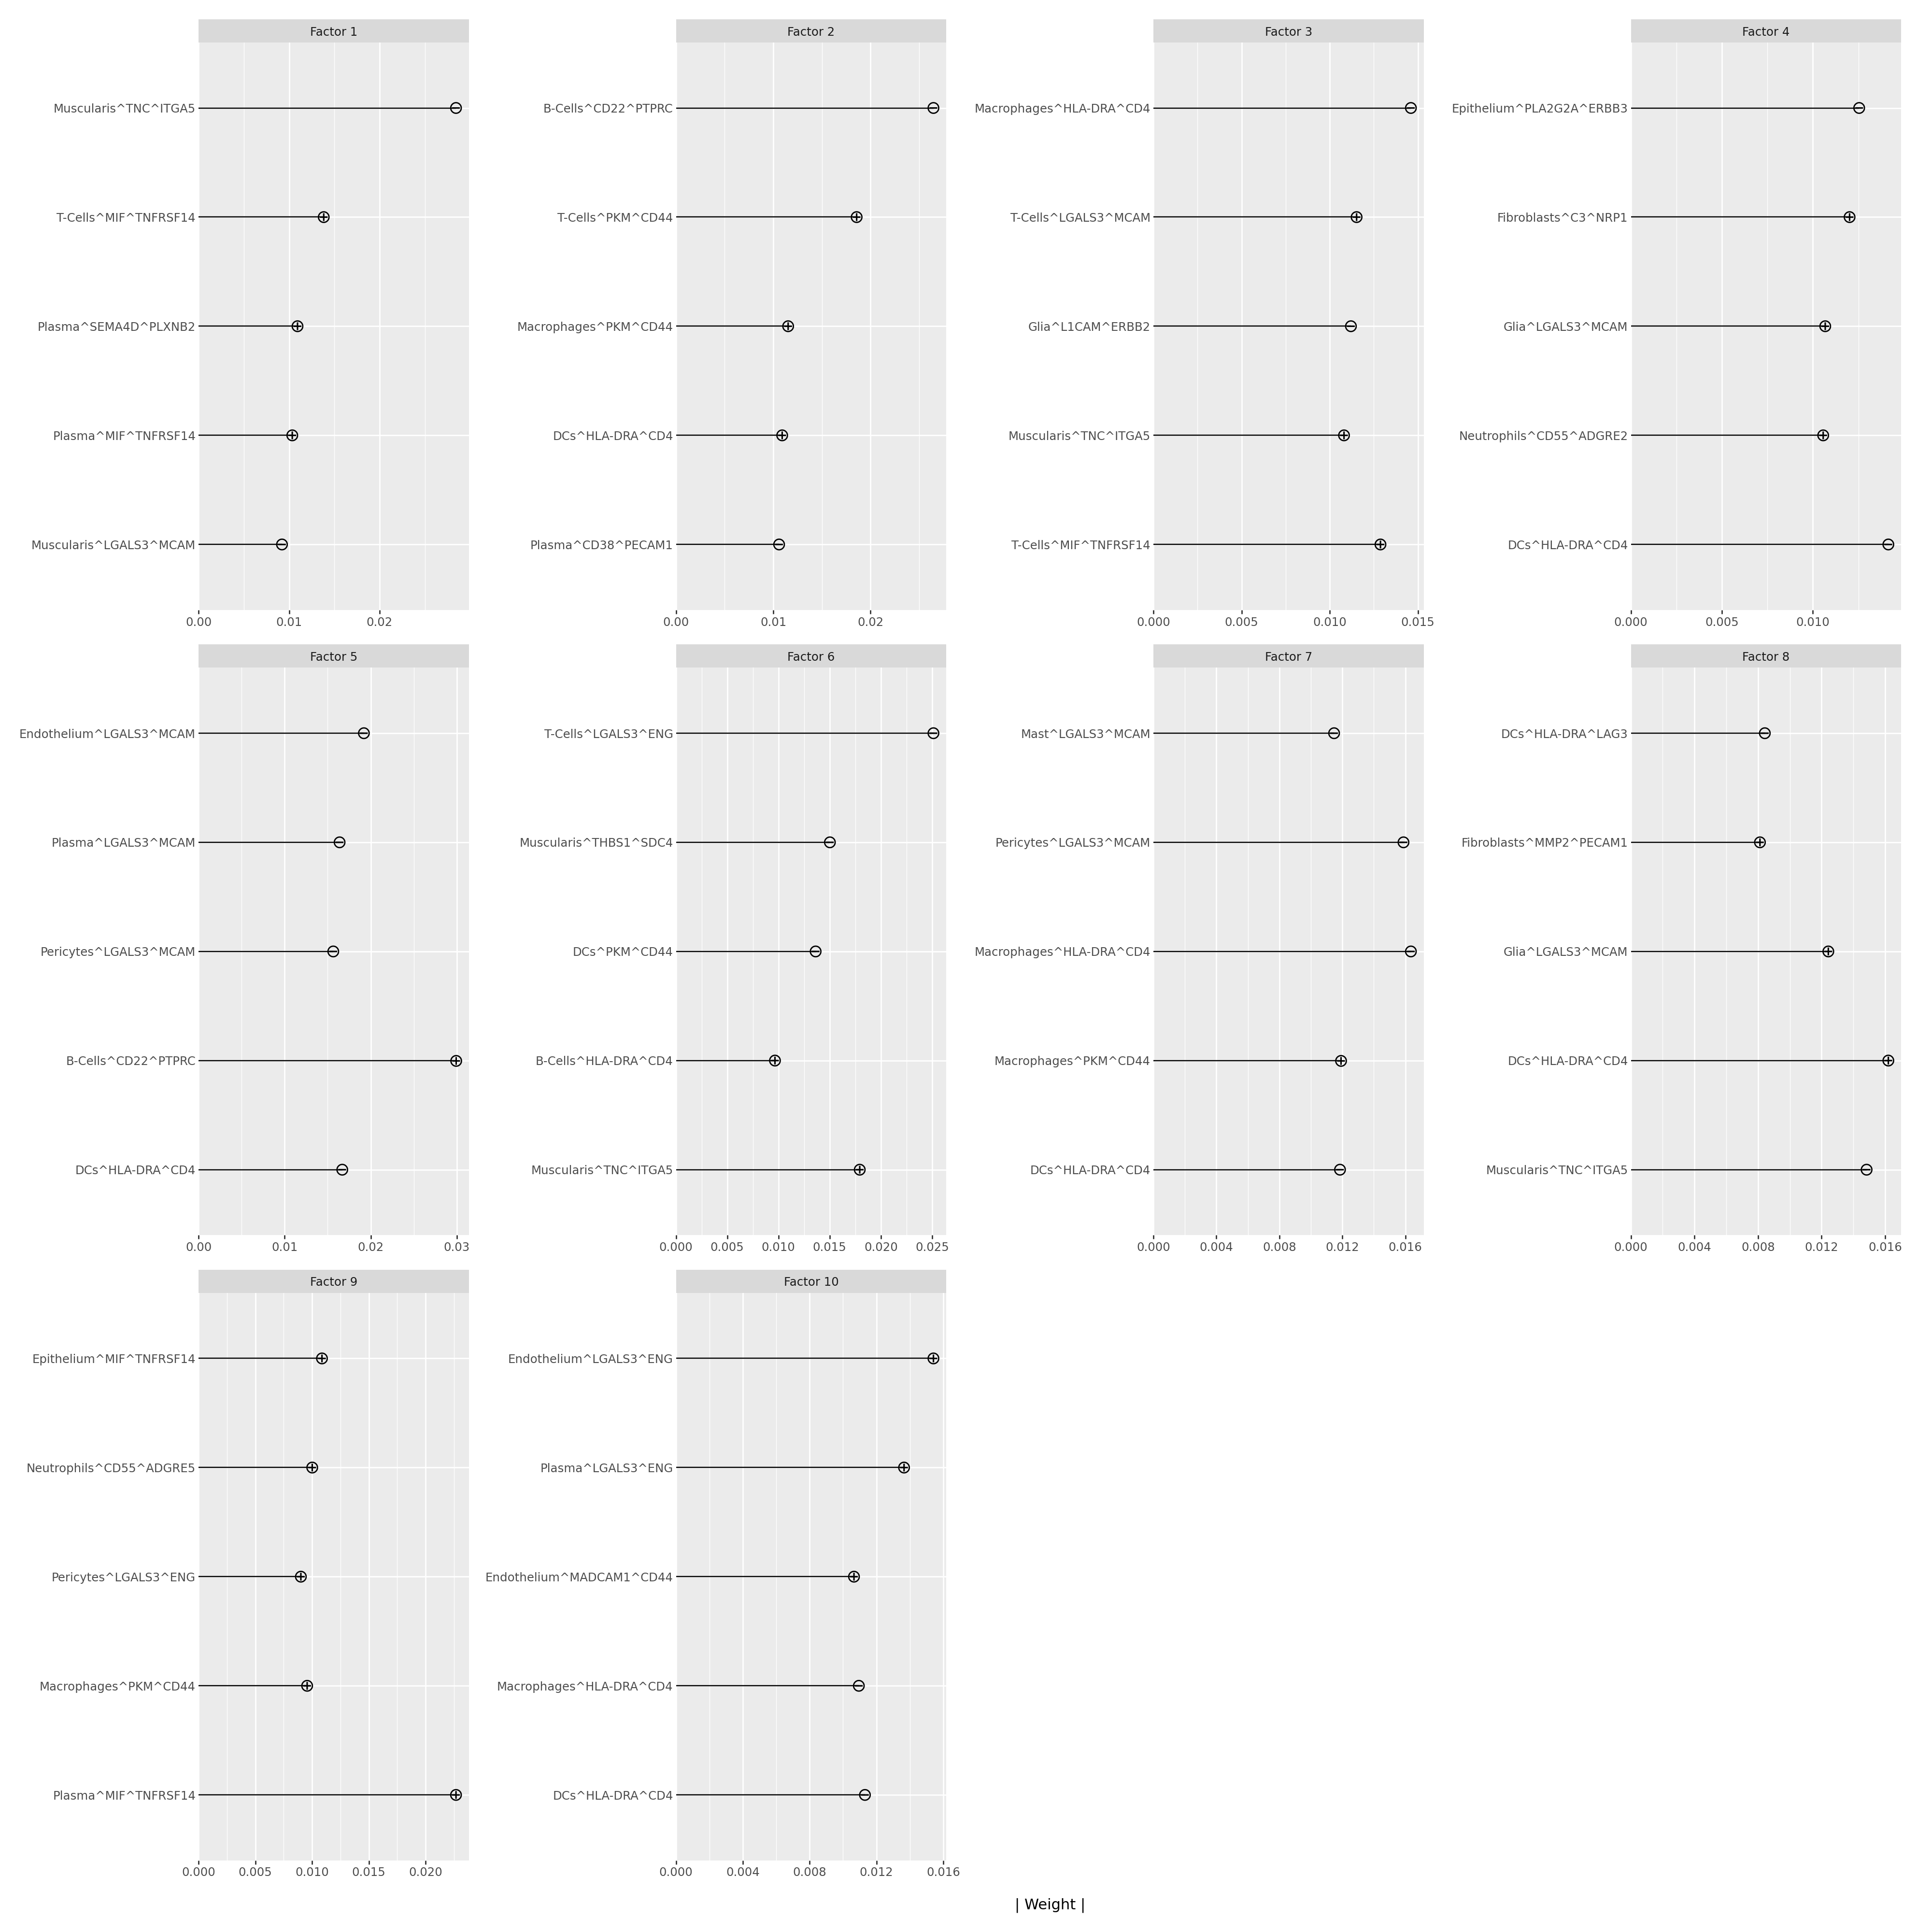

In [43]:
mfl.pl.top_weights(model, n_features=5, factors=None, figsize=(20, 20), nrow=None, ncol=None)

In [44]:
mdata.obsm['X_MOFA'] = factor_adata.X

In [45]:
mdata.obsm['X_MOFA']

ArrayView([[-0.5781633 ,  0.21614836, -0.42376903, ..., -0.84518987,
             0.17827347,  0.5523821 ],
           [-0.3815265 , -0.34987092, -0.15174143, ...,  0.78753793,
            -0.49522007, -0.5193574 ],
           [-0.6783232 ,  0.04209132,  0.21734516, ...,  0.04337987,
             0.07150415,  0.41695604],
           ...,
           [-0.73580146, -0.69924825,  0.8612955 , ...,  0.3686042 ,
             0.14444166,  0.8493498 ],
           [ 0.5396263 , -0.7879026 ,  0.57857347, ...,  0.7187056 ,
             0.37948227, -0.5544579 ],
           [ 0.753684  , -0.61808664,  0.6908748 , ...,  0.13923246,
             0.1606554 , -0.27483884]], shape=(191794, 10), dtype=float32)

In [ ]:
sc.pp.neighbors(factor_adata, use_rep='X')

In [ ]:
factor_adata

AnnData object with n_obs × n_vars = 191794 × 2
    obs: 'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
    uns: 'neighbors'
    obsp: 'distances', 'connectivities'

In [ ]:
sc.tl.umap(factor_adata, neighbors_key='neighbors')

... storing 'x' as categorical
... storing 'y' as categorical
... storing 'SAMPLE' as categorical
... storing 'TYPE' as categorical
... storing 'LOCATION' as categorical
... storing 'CellAnnotation.Level3' as categorical
... storing 'CellAnnotation.Level0' as categorical
... storing 'nCount_XENIUM_clean' as categorical
... storing 'nFeature_XENIUM_clean' as categorical
... storing 'cell_type' as categorical


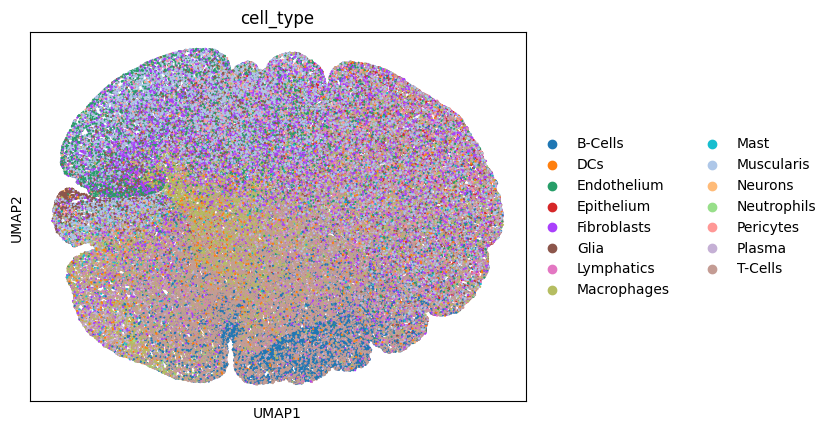

In [ ]:
sc.pl.umap(
    factor_adata,
    color=["cell_type"],
    # Setting a smaller point size to get prevent overlap
    size=10,
)

In [ ]:
sc.tl.leiden(factor_adata, resolution=0.5)

/tmp/ipykernel_1752154/420081657.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.


KeyboardInterrupt: 

In [ ]:
factor_adata.obsm['spatial'] = lrdata.obsm['spatial']

/tmp/ipykernel_1750359/2686565131.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


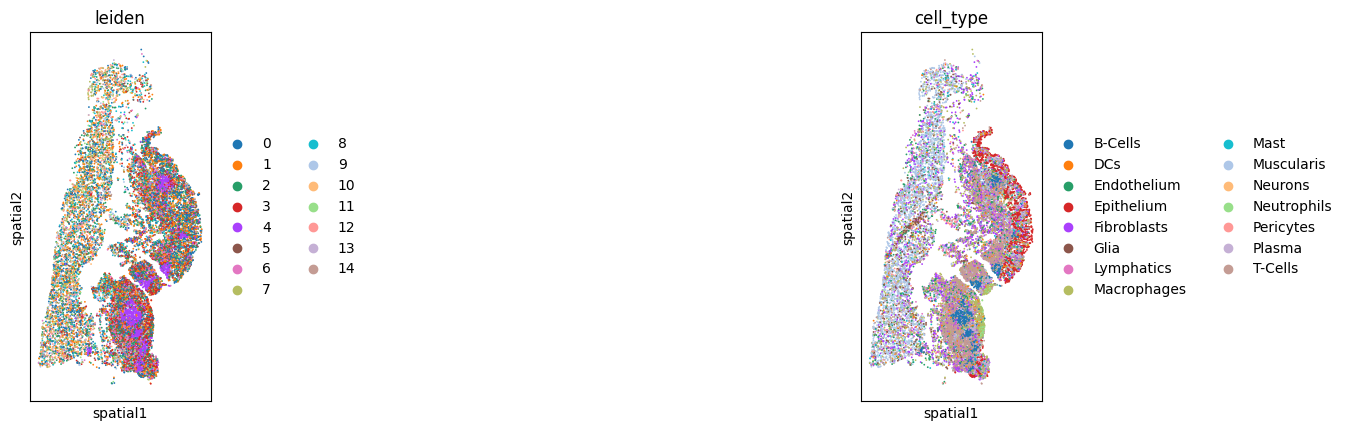

In [ ]:
sc.pl.spatial(factor_adata, basis="spatial", color=["leiden", "cell_type"], wspace=0.4, spot_size=50)

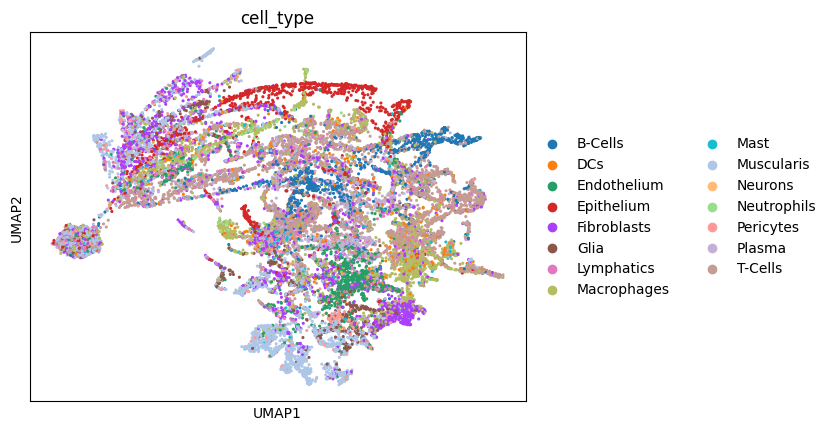

In [ ]:
sc.pp.pca(lrdata)
sc.pp.neighbors(lrdata, use_rep='X_pca')
sc.tl.umap(lrdata, neighbors_key='neighbors')
sc.pl.umap(
    lrdata,
    color=["cell_type"],
    # Setting a smaller point size to get prevent overlap
    size=20,
)

We will run simple Random forest model to find whether we can predict brain regions from latent factors or not.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
X = factor_adata.X  
y = factor_adata.obs["major_brain_region_ori"].values
le = LabelEncoder()
y_enc = le.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
#    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
# Evaluation
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.35260759493670885
                     precision    recall  f1-score   support

  Cortical_subplate       0.16      0.06      0.09       587
       Fiber_tracts       0.22      0.06      0.09      1210
        Hippocampus       0.41      0.10      0.16      1420
       Hypothalamus       0.37      0.22      0.27       974
          Isocortex       0.72      0.56      0.63      2663
          Olfactory       0.13      0.05      0.07       384
           Striatum       0.35      0.19      0.25       507
           Thalamus       0.24      0.79      0.37      1793
Ventricular_systems       0.16      0.04      0.07       337

           accuracy                           0.35      9875
          macro avg       0.31      0.23      0.22      9875
       weighted avg       0.40      0.35      0.32      9875



In [ ]:
from sklearn.metrics import roc_auc_score

y_proba = rf.predict_proba(X_test)

auc_macro = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="macro"
)

auc_weighted = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="weighted"
)

print("ROC-AUC (macro):   ", auc_macro)
print("ROC-AUC (weighted):", auc_weighted)

ROC-AUC (macro):    0.6591434811214135
ROC-AUC (weighted): 0.6939463020594471


In [ ]:
from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

per_class_auc = roc_auc_score(
    y_test_bin,
    y_proba,
    average=None
)

for cls, auc in zip(le.classes_, per_class_auc):
    print(f"{cls}: AUC = {auc:.3f}")


Cortical_subplate: AUC = 0.596
Fiber_tracts: AUC = 0.665
Hippocampus: AUC = 0.695
Hypothalamus: AUC = 0.641
Isocortex: AUC = 0.819
Olfactory: AUC = 0.570
Striatum: AUC = 0.649
Thalamus: AUC = 0.632
Ventricular_systems: AUC = 0.666


Note: nice and expected, isocortext has a unique signal

### sanity check (shuffle and re-train)


In [ ]:
y_train_shuffled = y_train.copy()
rng = np.random.default_rng(42)
rng.shuffle(y_train_shuffled)
rf_shuffled = RandomForestClassifier(
    n_estimators=300,
    n_jobs=-1,
    random_state=42
)

rf_shuffled.fit(X_train, y_train_shuffled)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

y_pred_shuf = rf_shuffled.predict(X_test)
y_proba_shuf = rf_shuffled.predict_proba(X_test)

acc_shuf = accuracy_score(y_test, y_pred_shuf)

auc_macro_shuf = roc_auc_score(
    y_test,
    y_proba_shuf,
    multi_class="ovr",
    average="macro"
)

auc_weighted_shuf = roc_auc_score(
    y_test,
    y_proba_shuf,
    multi_class="ovr",
    average="weighted"
)

print("Shuffled accuracy:", acc_shuf)
print("Shuffled AUC (macro):", auc_macro_shuf)
print("Shuffled AUC (weighted):", auc_weighted_shuf)


Shuffled accuracy: 0.15848101265822784
Shuffled AUC (macro): 0.5112363825087648
Shuffled AUC (weighted): 0.5062948981046312


In [ ]:
auc_macros = []

for seed in range(10):
    y_shuf = y_train.copy()
    np.random.default_rng(seed).shuffle(y_shuf)

    rf.fit(X_train, y_shuf)
    y_proba = rf.predict_proba(X_test)

    auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class="ovr",
        average="macro"
    )
    auc_macros.append(auc)

print("Shuffled AUC mean ± std:",
      np.mean(auc_macros), np.std(auc_macros))


Shuffled AUC mean ± std: 0.5112331968653164 0.002021042442310331


----